# Goal
* Extend probabilisticly

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import ot
from scipy.spatial.transform import Rotation as R


from AdjQuat.solutions import make_R_tilde, make_R_tilde_prob, make_dets, make_dets_prob, make_M_opt_rot_prob
from AdjQuat.procrustes_wasserstein import procrustes_wasserstein_2d_3d_dram_prob


# Symbol "7": with keypoints

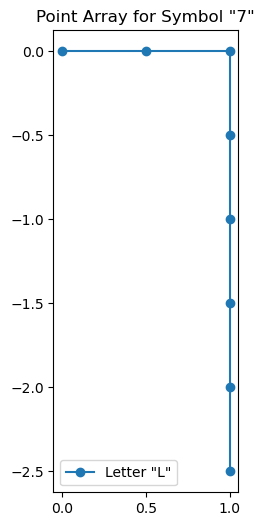

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define points for the letter "L"
top_points = np.array([[0, 0], [0.5, 0], [1, 0]])  # 3 points on the top
side_points = np.array([[1, -0.5], [1, -1], [1, -1.5], [1, -2], [1, -2.5]])  # 5 points on the side

# Combine the points
points_L = np.vstack((top_points, side_points))

# Plot the points to visualize the letter "L"
plt.figure(figsize=(6, 6))
plt.plot(points_L[:, 0], points_L[:, 1], 'o-', label='Letter "L"')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Point Array for Symbol "7"')
plt.legend()
plt.show()

In [4]:
points_L.shape

(8, 2)

Sample 3 new points per keypoints

In [85]:
n_point_per_keypiont = 3
torch.manual_seed(0)
UV_noise = torch.randn(size=(n_point_per_keypiont,) + points_L.shape)

In [176]:
xyz_init = torch.zeros(8,3)
xyz_init[:,:2] = torch.from_numpy(points_L)
noise_3d_scale = 0.03
xyz_init[:,2] = 1 + noise_3d_scale*torch.randn(len(xyz_init))
deg = 0
rotation_matrix = R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32)
xyz = xyz_init @ rotation_matrix
noise_scale = 0.001
d2 = 2
UV = (xyz[:,:d2].repeat(n_point_per_keypiont, 1, 1) + noise_scale*UV_noise).reshape(-1,2)

/tmp/ipykernel_1851777/2423016646.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  xyz = xyz_init @ rotation_matrix


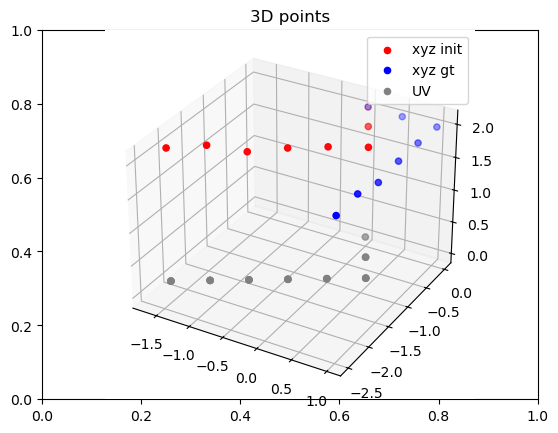

In [164]:
fig, ax = plt.subplots(1,1)

ax2 = fig.add_subplot(1,1,1, projection='3d')
ax2.scatter(xs=xyz[:, 0], ys=xyz[:, 1], zs=xyz[:, 2] + 1, label='xyz init', marker='o', color='red')
ax2.scatter(xs=xyz_init[:, 0], ys=xyz_init[:, 1], zs=xyz_init[:, 2] + 1, label='xyz gt', marker='o', color='blue')
ax2.scatter(xs=UV[:, 0], ys=UV[:, 1], zs=0, label='UV', marker='o', color='gray')
ax2.set_title('3D points')
ax2.legend()

Transport plan

Text(0.5, 1.0, 'Transport Plan (joint distribution)')

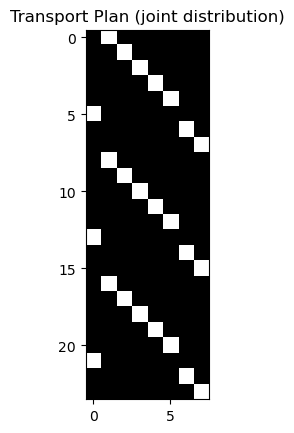

In [165]:
C = torch.cdist(UV, xyz_init[:,:d2], p=2) ** 2
p = torch.ones(len(UV)) / len(UV)
q = torch.ones(len(xyz_init)) / len(xyz)
transport_plan, log = ot.emd(p.numpy(), q.numpy(), C.numpy(), log=True)

plt.imshow(transport_plan, cmap='gray')
plt.title('Transport Plan (joint distribution)')

In [166]:
transport_plan.sum()

np.float32(1.0)

In [168]:
rotation = torch.from_numpy(R.from_euler('z', 60, degrees=True).as_matrix()).float()

make_dets(xyz_init @ rotation, xyz_init[:,:2])

(np.float32(39.02819),
 np.float32(2.84144e-05),
 np.float32(-7.0538636e-07),
 np.float32(33.799374),
 np.float32(-19.514097),
 np.float32(-1.359632e-05),
 np.float32(19.514074),
 np.float32(33.7994),
 np.float32(2.4960284e-05),
 np.float32(39.028152))

In [169]:
rotation_est = make_R_tilde(xyz_init @ rotation, xyz_init[:,:2])
rotation_est, rotation, np.linalg.norm(rotation_est - rotation.numpy())

(array([[ 4.9999946e-01, -8.6602461e-01,  7.2804812e-07],
        [ 8.6602527e-01,  5.0000006e-01, -1.8073765e-08],
        [-3.4837177e-07,  6.3954496e-07,  9.9999905e-01]], dtype=float32),
 tensor([[ 0.5000, -0.8660,  0.0000],
         [ 0.8660,  0.5000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]]),
 np.float32(1.6959358e-06))

In [170]:
make_dets_prob(xyz_init @ rotation, UV, transport_plan.T)

(np.float32(0.076226935),
 np.float32(-0.05823932),
 np.float32(-0.09117706),
 np.float32(0.06280406),
 np.float32(0.032208093),
 np.float32(0.0505138),
 np.float32(0.11243735),
 np.float32(0.08529001),
 np.float32(0.06932557),
 np.float32(0.022763165))

In [171]:
rotation_est = make_R_tilde_prob(xyz @ rotation, UV, transport_plan.T)
rotation_est, rotation, np.linalg.norm(rotation_est - rotation.numpy())

(array([[ 0.02399071, -1.6893728 , -0.7640262 ],
        [ 0.19352694, -1.1802572 , -1.1961269 ],
        [ 1.1189569 , -0.11916371,  0.29862395]], dtype=float32),
 tensor([[ 0.5000, -0.8660,  0.0000],
         [ 0.8660,  0.5000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]]),
 np.float32(2.8200448))

In [172]:
rotation_est = make_M_opt_rot_prob(xyz @ rotation, UV, transport_plan.T)
rotation_est, rotation, np.linalg.norm(rotation_est - rotation.numpy())

(array([[-0.13657667, -0.98341564,  0.11933354],
        [ 0.24003019, -0.14972434, -0.95914969],
        [ 0.96110994, -0.10235382,  0.2564983 ]]),
 tensor([[ 0.5000, -0.8660,  0.0000],
         [ 0.8660,  0.5000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]]),
 np.float64(1.9116051015386846))

## procrustes_wasserstein_2d_3d_dram_prob

In [173]:
xyz.dtype, UV.dtype

(torch.float32, torch.float32)

In [ ]:
try:
    del procrustes_wasserstein_2d_3d_dram_prob
except Exception as e:
    print(e)
    pass
from AdjQuat.procrustes_wasserstein import procrustes_wasserstein_2d_3d_dram_prob


degs = np.linspace(0, 90, 90)
errors = []
logs_degs = []
for deg in degs:
    rotation = R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32)

    # rotation_est = make_M_opt_rot_prob(all_coords_subset_scaled @ rotation, UV, transport_plan.T)
    
    transport_plan, rotation_est, logs = procrustes_wasserstein_2d_3d_dram_prob(xyz_init @ rotation, UV, max_iter=9, verbose_log=True)
    error = np.linalg.norm(rotation_est - rotation)
    errors.append(error)
    logs_degs.append(logs)

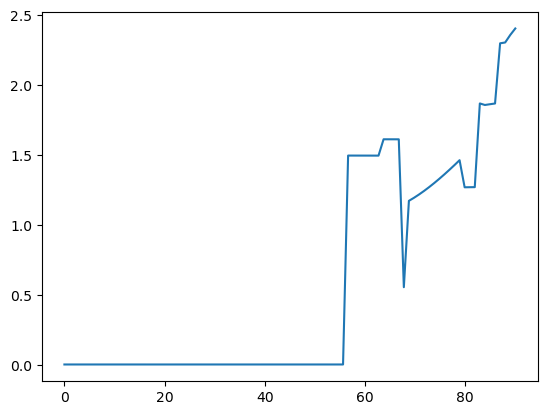

In [178]:
plt.plot(degs[:len(errors)], errors)

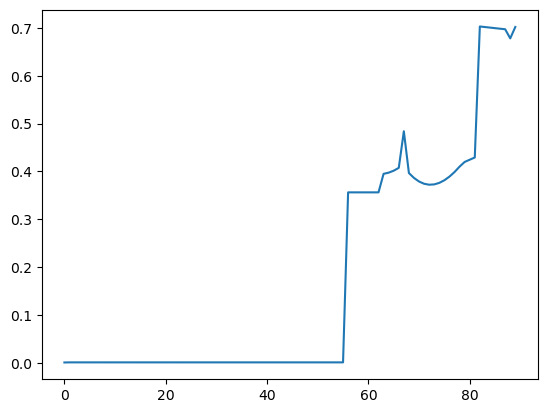

In [180]:
plt.plot([min([log['point_norm'] for log in logs_degs[idx]]) for idx in range(len(logs_degs))])

## Fit keypionts to image
- make "L" from gaussian blobs
- keypoint and get xy coords directly from image
- make some random noisy z points

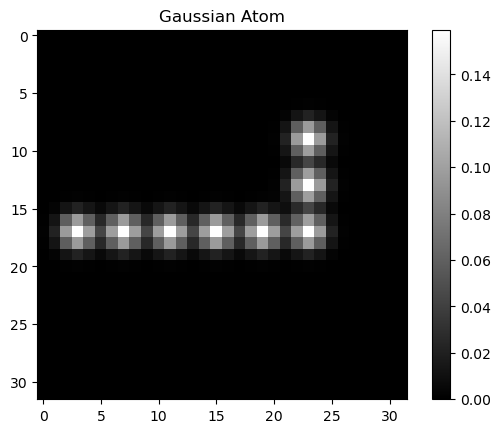

In [44]:
def gauss_2d(x, y, mu_x, mu_y, sigma=1):
    x_ = x - mu_x
    y_ = y - mu_y
    return np.exp(-(x_**2 + y_**2) / (2 * sigma**2)) / (2 * np.pi * sigma**2)

n_pix = 32
grid_1d = np.arange(n_pix) - n_pix//2
xg, yg = np.meshgrid(grid_1d, grid_1d, indexing='ij')
coords = np.stack([xg.flatten(),yg.flatten()]).T
sigma = 1
image = np.zeros((n_pix, n_pix))
scaled_points_L = (points_L - points_L.mean(axis=0))*n_pix//4
for atom in scaled_points_L:
    atom = atom[:2]
    gaussian = gauss_2d(coords[:,0], coords[:,1], atom[0], atom[1], sigma).reshape(n_pix, n_pix)
    image += gaussian
plt.imshow(image, cmap='gray')
plt.title('Gaussian Atom')
plt.colorbar()
plt.show()


In [45]:
n_keypoints = 8
idx_keypoints = np.argsort(image.flatten())[-n_keypoints:]
coords_keypoints = coords[idx_keypoints]
coords_keypoints + n_pix//2

array([[ 9, 23],
       [17,  3],
       [17,  7],
       [17, 11],
       [17, 15],
       [17, 23],
       [13, 23],
       [17, 19]])

In [89]:
xyz_init = torch.zeros(n_keypoints,3)
xyz_init[:,:2] = torch.from_numpy(coords_keypoints)
noise_3d_level = 0.01
z_offset = 0.00
xyz_init[:,-1] = z_offset + noise_3d_level*torch.randn(n_keypoints)
xyz_init

tensor([[-7.0000e+00,  7.0000e+00,  6.4264e-03],
        [ 1.0000e+00, -1.3000e+01, -2.7260e-02],
        [ 1.0000e+00, -9.0000e+00,  5.4166e-03],
        [ 1.0000e+00, -5.0000e+00, -5.5117e-03],
        [ 1.0000e+00, -1.0000e+00,  2.6589e-03],
        [ 1.0000e+00,  7.0000e+00,  1.0439e-03],
        [-3.0000e+00,  7.0000e+00, -6.2013e-03],
        [ 1.0000e+00,  3.0000e+00,  7.4822e-03]])

In [ ]:
deg = 45
rotation = torch.from_numpy(R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32))
UV = torch.from_numpy(coords).to(rotation.dtype)
transport_plan, rotation_est, logs = procrustes_wasserstein_2d_3d_dram_prob(xyz_init @ rotation, UV, UV_ditribution = torch.from_numpy(image.flatten() / image.sum()), max_iter=20, verbose_log=True)
np.linalg.norm(rotation_est - rotation.numpy())

In [92]:
# import pandas as pd
# pd.Series(image.flatten()).sort_values(ascending=False).head(n_keypoints*9).index.tolist()

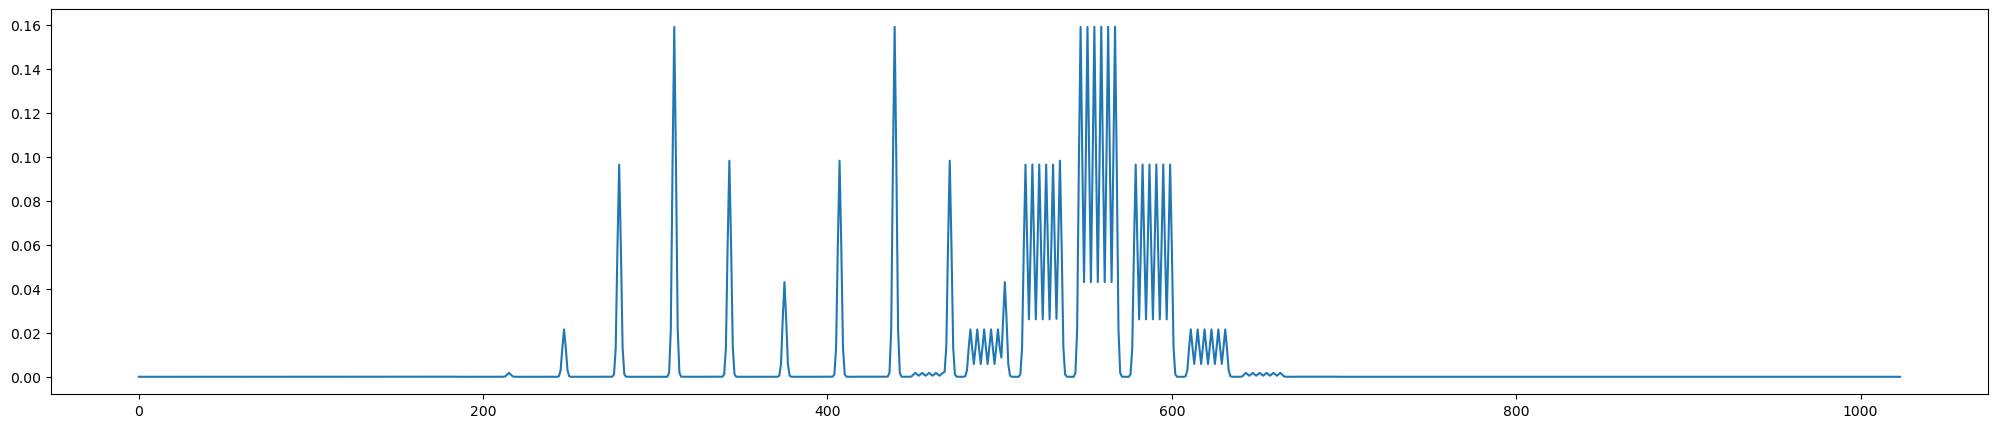

In [93]:
fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(image.flatten())

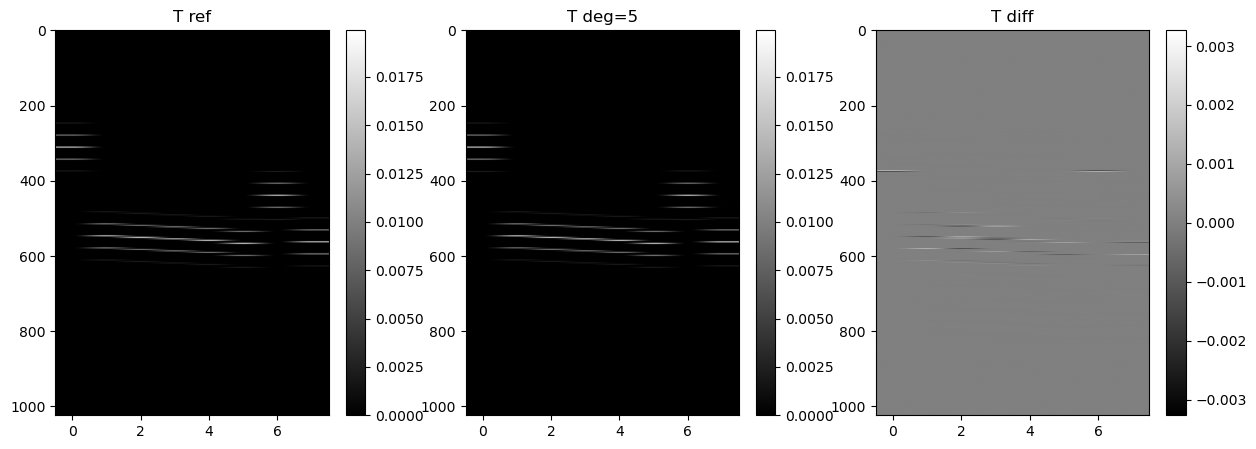

In [94]:
d2 = 2
deg = 0
rotation = torch.from_numpy(R.from_euler('z', deg, degrees=True).as_matrix()).float()
C = torch.cdist(UV, (xyz_init @ rotation)[:,:d2], p=2) ** 2
p = torch.from_numpy(image.flatten() / image.sum())
q = torch.ones(len(xyz_init)) / len(xyz_init)
transport_plan_ref, log = ot.emd(p.numpy(), q.numpy(), C.numpy(), log=True)

d2 = 2
deg = 5
rotation = torch.from_numpy(R.from_euler('z', deg, degrees=True).as_matrix()).float()
C = torch.cdist(UV, (xyz_init @ rotation)[:,:d2], p=2) ** 2
p = torch.from_numpy(image.flatten() / image.sum())
q = torch.ones(len(xyz_init)) / len(xyz_init)
transport_plan_deg, log = ot.emd(p.numpy(), q.numpy(), C.numpy(), log=True)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(transport_plan_ref, cmap='gray', aspect='auto')
axes[0].set_title('T ref')
fig.colorbar(im, ax=axes[0])

im = axes[1].imshow(transport_plan_deg, cmap='gray', aspect='auto')
axes[1].set_title(f'T deg={deg}')
fig.colorbar(im, ax=axes[1])

im = axes[2].imshow(transport_plan_ref - transport_plan_deg, cmap='gray', aspect='auto')
axes[2].set_title('T diff')
fig.colorbar(im, ax=axes[2])



In [95]:
# pd.Series(transport_plan[:,0]).sort_values(ascending=False).head(10)

In [96]:
deg = 45
rotation = torch.from_numpy(R.from_euler('z', deg, degrees=True).as_matrix()).float()
rotation_est = make_M_opt_rot_prob(xyz_init @ rotation, UV, transport_plan.T.astype(np.float32))
rotation_est, rotation, np.linalg.norm(rotation_est - rotation.numpy())

(array([[ 0.67543547, -0.5264964 ,  0.51632206],
        [ 0.73063651,  0.57255231, -0.37195986],
        [-0.09978586,  0.62847863,  0.77139963]]),
 tensor([[ 0.7071, -0.7071,  0.0000],
         [ 0.7071,  0.7071,  0.0000],
         [ 0.0000,  0.0000,  1.0000]]),
 np.float64(0.9562557620268094))

In [ ]:
del procrustes_wasserstein_2d_3d_dram_prob
from AdjQuat.procrustes_wasserstein import procrustes_wasserstein_2d_3d_dram_prob


degs = np.linspace(0, 90, 90)
errors = []
logs_degs = []
for deg in degs:
    rotation = R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32)

    # rotation_est = make_M_opt_rot_prob(all_coords_subset_scaled @ rotation, UV, transport_plan.T)
    
    transport_plan, rotation_est, logs = procrustes_wasserstein_2d_3d_dram_prob(xyz_init @ rotation, UV, UV_ditribution = torch.from_numpy(image.flatten() / image.sum()), max_iter=10, verbose_log=True)
    error = np.linalg.norm(rotation_est - rotation)
    errors.append(error)
    logs_degs.append(logs)

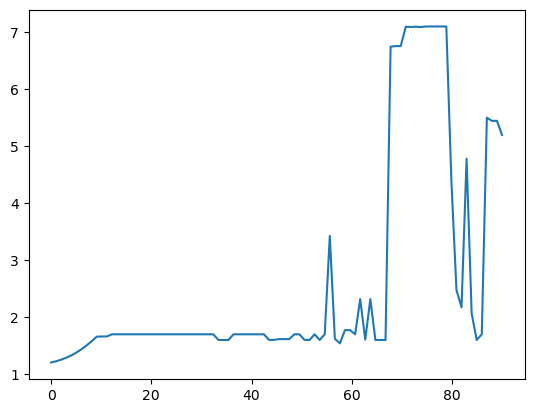

In [98]:
plt.plot(degs, [min([log['point_norm'] for log in logs_degs[idx]]) for idx in range(len(logs_degs))])

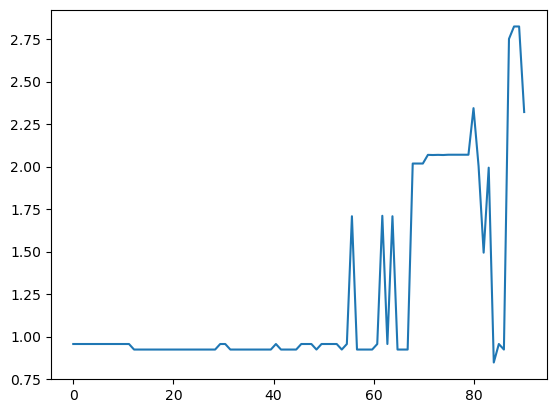

In [99]:
plt.plot(degs[:len(errors)], errors)

# Ribosome

In [45]:
import gemmi

# Load CIF file
fname = 'data/4UG0.cif'

In [46]:
# Read the structure from the CIF file
structure = gemmi.read_structure(fname)

# Access the first model in the structure
model = structure[0]  # Assumes one model in the file

# Extract coordinates of all atoms
all_coords = np.array([
    [atom.pos.x, atom.pos.y, atom.pos.z]
    for chain in model
    for residue in chain
    for atom in residue
    if atom.name == "CA"  # Filter only Cα atoms
])
n_atoms = len(all_coords) 
rand_idx = torch.randperm(len(all_coords))[:n_atoms]
all_coords_subset = torch.from_numpy(all_coords[rand_idx])

# make 2D image with histograming

In [47]:
n_pix = 64
image, _, _ = np.histogram2d(all_coords_subset[:,0], all_coords_subset[:,1], bins=n_pix)

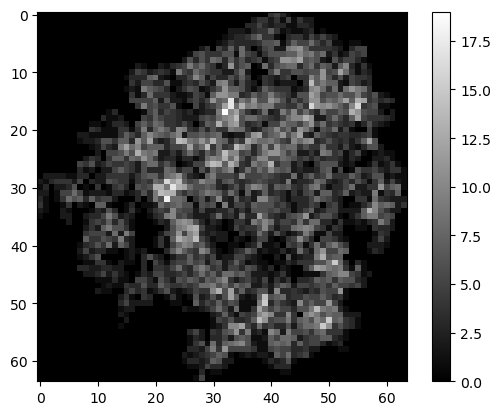

In [48]:
plt.imshow(image, cmap='gray')
plt.colorbar()

In [49]:
grid_1d = torch.arange(n_pix) - n_pix//2
x_grid, y_grid = torch.meshgrid(grid_1d, grid_1d, indexing='ij')
UV = torch.stack((x_grid.flatten(), y_grid.flatten()), dim=1).double()

In [50]:
all_coords_subset_scaled = all_coords_subset - all_coords_subset.mean(0)
all_coords_subset_scaled /= all_coords_subset_scaled.abs().max()
all_coords_subset_scaled * n_pix//2

cost = torch.cdist(UV, all_coords_subset_scaled[:,:2], p=2) ** 2
p = torch.ones(len(UV)) / len(UV)
q = torch.ones(len(all_coords_subset_scaled)) / len(all_coords_subset_scaled)
transport_plan, log = ot.emd(p.numpy(), q.numpy(), cost.numpy(), log=True,)


/mnt/home/gwoollard/ceph/envs/quaternion_adjugate/lib/python3.11/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


In [51]:
make_R_tilde_prob(all_coords_subset_scaled, UV, transport_plan.T)

array([[ 3.22649864e+01,  5.08777507e-01, -7.42312810e-01],
       [ 6.27606410e-01,  3.71736209e+01,  2.15859404e-01],
       [ 2.77042794e+01, -7.43058103e+00,  1.19908706e+03]])

In [52]:
make_M_opt_rot_prob(all_coords_subset_scaled, UV, transport_plan.T)

array([[ 0.99973163, -0.00163667, -0.02310842],
       [ 0.00177936,  0.99997947,  0.00615563],
       [ 0.02309787, -0.00619509,  0.99971401]])

In [53]:
transport_plan.sum(0)

array([8.5653104e-05, 0.0000000e+00, 8.5653111e-05, ..., 8.5653104e-05,
       8.5653104e-05, 8.5653104e-05], shape=(11675,), dtype=float32)

/tmp/ipykernel_2081044/202460425.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rotation_est = make_M_opt_rot_prob(all_coords_subset_scaled @ rotation, UV, transport_plan.T)


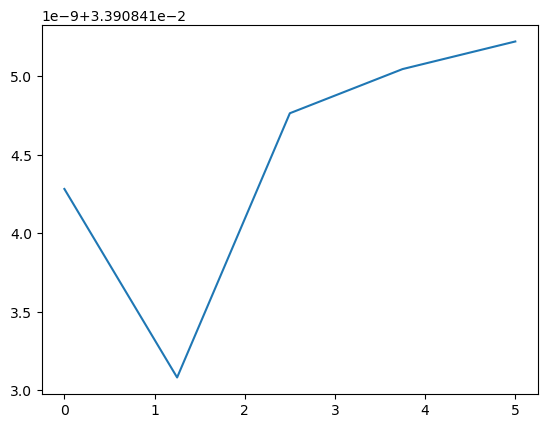

In [54]:
degs = np.linspace(0, 5, 5)
errors = []

for deg in degs:
    rotation = R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32)

    rotation_est = make_M_opt_rot_prob(all_coords_subset_scaled @ rotation, UV, transport_plan.T)
    error = np.linalg.norm(rotation_est - rotation)
    errors.append(error)

plt.plot(degs, errors)

In [ ]:
deg = 25
rotation = R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32)
transport_plan, rotation_est, logs = procrustes_wasserstein_2d_3d_dram_prob(all_coords_subset_scaled @ rotation, UV, UV_ditribution = torch.from_numpy(image.flatten() / image.sum()), max_iter=40, verbose_log=True, emd_kwargs={'numItermax':10**6})
error = np.linalg.norm(rotation_est - rotation)
rotation, rotation_est, error

/tmp/ipykernel_2015365/3554889505.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rotation_error = [np.linalg.norm(log['R'] - rotation) for log in logs]


Text(0.5, 1.0, 'Transport Cost')

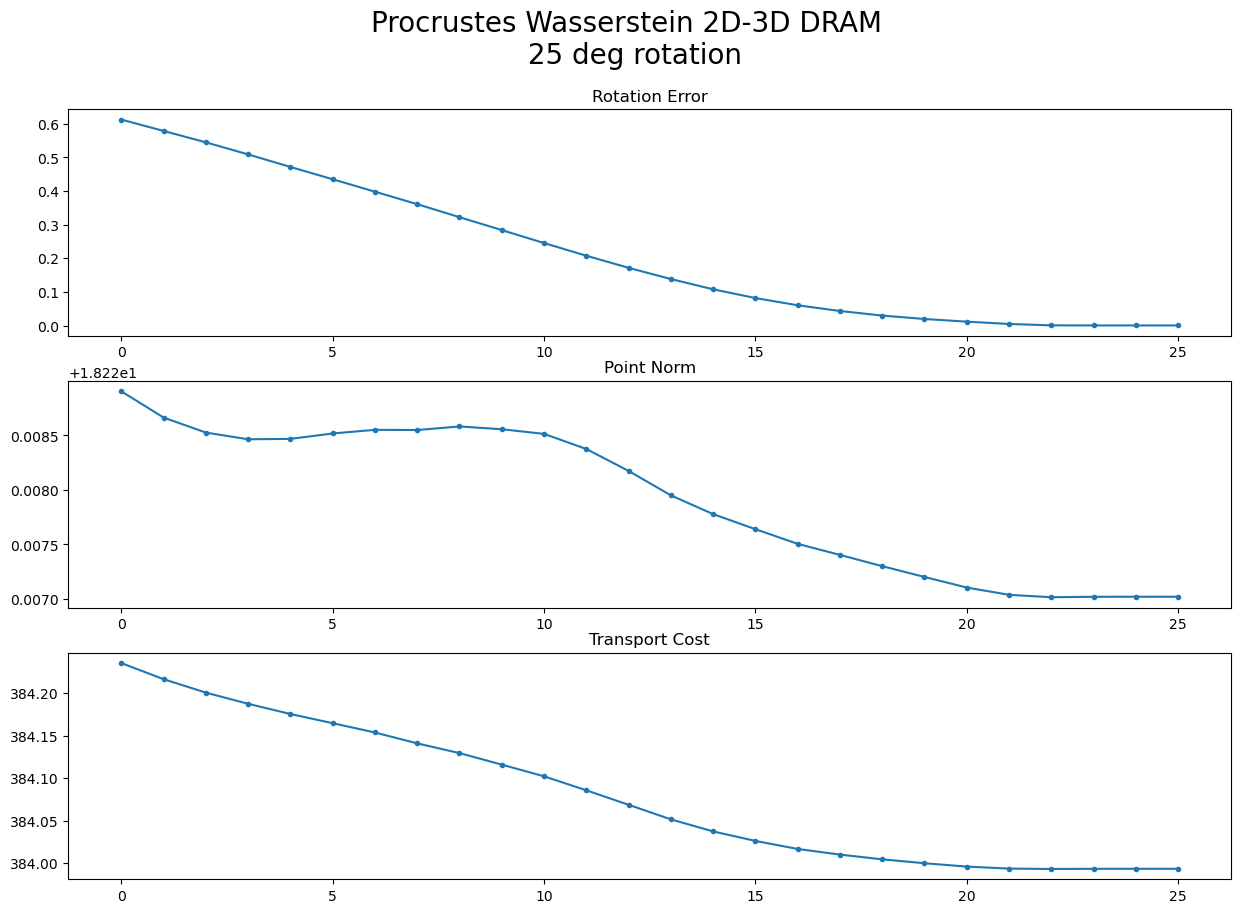

In [47]:
rotation_error = [np.linalg.norm(log['R'] - rotation) for log in logs]
point_norm = [log['point_norm'] for log in logs]
transport_cost = [log['cost'] for log in logs]

# plot all three on panels
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
plt.suptitle(f'Procrustes Wasserstein 2D-3D DRAM \n {deg} deg rotation', fontsize=20)

axes[0].plot(rotation_error, marker='.')
axes[0].set_title('Rotation Error')
axes[1].plot(point_norm, marker='.')
axes[1].set_title('Point Norm')
axes[2].plot(transport_cost, marker='.')
axes[2].set_title('Transport Cost')

/tmp/ipykernel_2015365/629150117.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  all_coords_subset_scaled_rot_ref = all_coords_subset_scaled @ rotation
/tmp/ipykernel_2015365/629150117.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  all_coords_subset_scaled_rot_est = all_coords_subset_scaled @ rotation_est


Text(0.5, 1.0, 'Image Difference (Init - Est)')

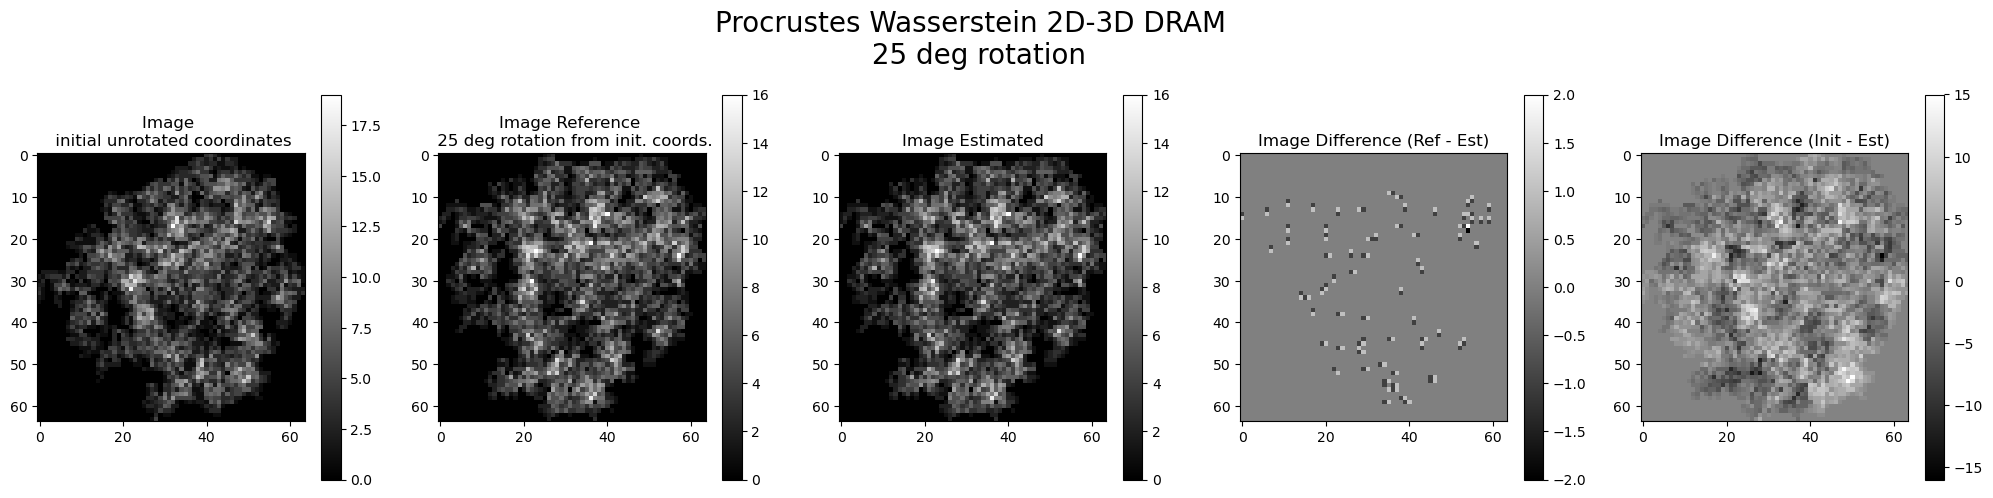

In [48]:
n_pix = 64

all_coords_subset_scaled_rot_ref = all_coords_subset_scaled @ rotation
all_coords_subset_scaled_rot_est = all_coords_subset_scaled @ rotation_est
image_init, _, _ = np.histogram2d(all_coords_subset_scaled[:,0], all_coords_subset_scaled[:,1], bins=n_pix)
image_ref, _, _ = np.histogram2d(all_coords_subset_scaled_rot_ref[:,0], all_coords_subset_scaled_rot_ref[:,1], bins=n_pix)
image_est, _, _ = np.histogram2d(all_coords_subset_scaled_rot_est[:,0], all_coords_subset_scaled_rot_est[:,1], bins=n_pix)

n_plots = 5
base = 5
fig, axes = plt.subplots(1, 5, figsize=(base*n_plots, base))
plt.suptitle(f'Procrustes Wasserstein 2D-3D DRAM \n {deg} deg rotation', fontsize=20, y=1.05)

idx = 0
im = axes[idx].imshow(image_init, cmap='gray')
fig.colorbar(im, ax=axes[idx])
axes[idx].set_title('Image \n initial unrotated coordinates')

idx += 1
im = axes[idx].imshow(image_ref, cmap='gray')
fig.colorbar(im, ax=axes[idx])
axes[idx].set_title(f'Image Reference \n {deg} deg rotation from init. coords.')

idx += 1
im = axes[idx].imshow(image_est, cmap='gray')
fig.colorbar(im, ax=axes[idx])
axes[idx].set_title('Image Estimated')

idx += 1
im = axes[idx].imshow(image_ref - image_est, cmap='gray')
fig.colorbar(im, ax=axes[idx])
axes[idx].set_title('Image Difference (Ref - Est)')

idx += 1
im = axes[idx].imshow(image_init - image_ref, cmap='gray')
fig.colorbar(im, ax=axes[idx])
axes[idx].set_title('Image Difference (Init - Est)')

In [17]:
del procrustes_wasserstein_2d_3d_dram_prob
from AdjQuat.procrustes_wasserstein import procrustes_wasserstein_2d_3d_dram_prob


In [ ]:
del procrustes_wasserstein_2d_3d_dram_prob
from AdjQuat.procrustes_wasserstein import procrustes_wasserstein_2d_3d_dram_prob


degs = np.linspace(0, 20, 5)
errors = []
logs_degs = []
for deg in degs:
    rotation = R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32)

    # rotation_est = make_M_opt_rot_prob(all_coords_subset_scaled @ rotation, UV, transport_plan.T)
    
    transport_plan, rotation_est, logs = procrustes_wasserstein_2d_3d_dram_prob(all_coords_subset_scaled @ rotation, UV, UV_ditribution = torch.from_numpy(image.flatten() / image.sum()), max_iter=10, verbose_log=True)
    error = np.linalg.norm(rotation_est - rotation)
    errors.append(error)
    logs_degs.append(logs)

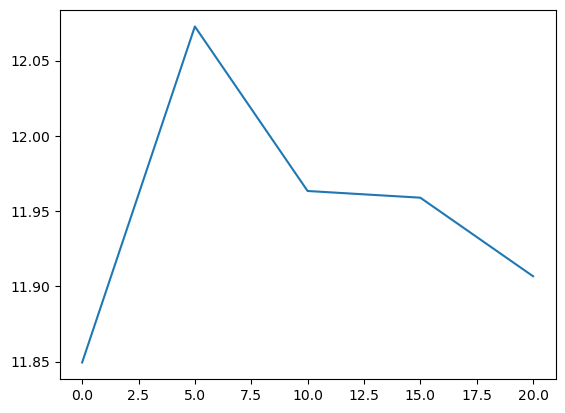

In [128]:
plt.plot(degs, [min([log['point_norm'] for log in logs_degs[idx]]) for idx in range(len(logs_degs))])

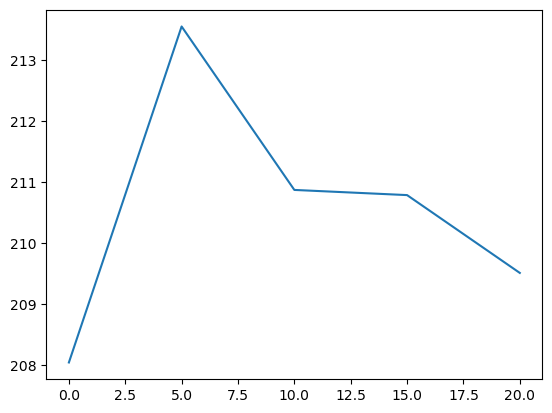

In [129]:
plt.plot(degs, [min([log['cost'] for log in logs_degs[idx]]) for idx in range(len(logs_degs))])

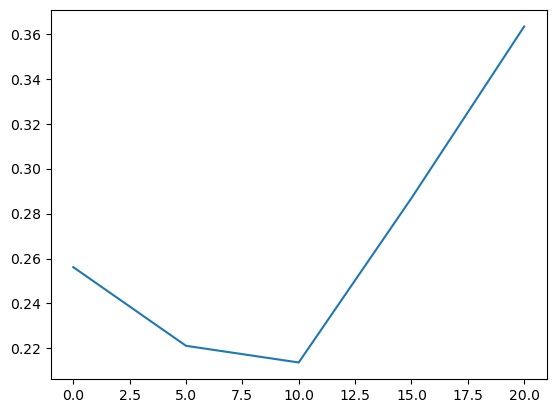

In [130]:
plt.plot(degs[:len(errors)], errors)

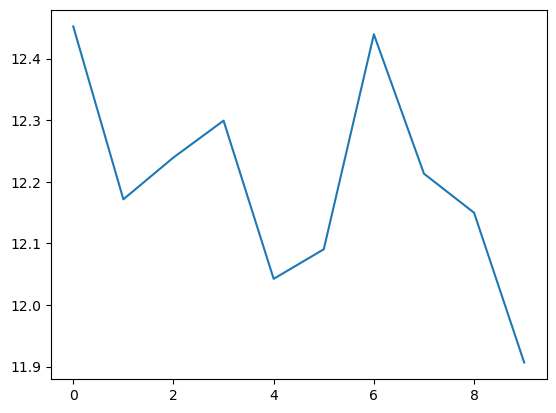

In [132]:
plt.plot([log['point_norm'] for log in logs_degs[-1]])

# Noise (poisson)
- $y_i \sim \text{Poi}[x_i + \lambda]$
- $SNR = \lambda / \text{Var}[x]$

In [9]:
image

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(64, 64))

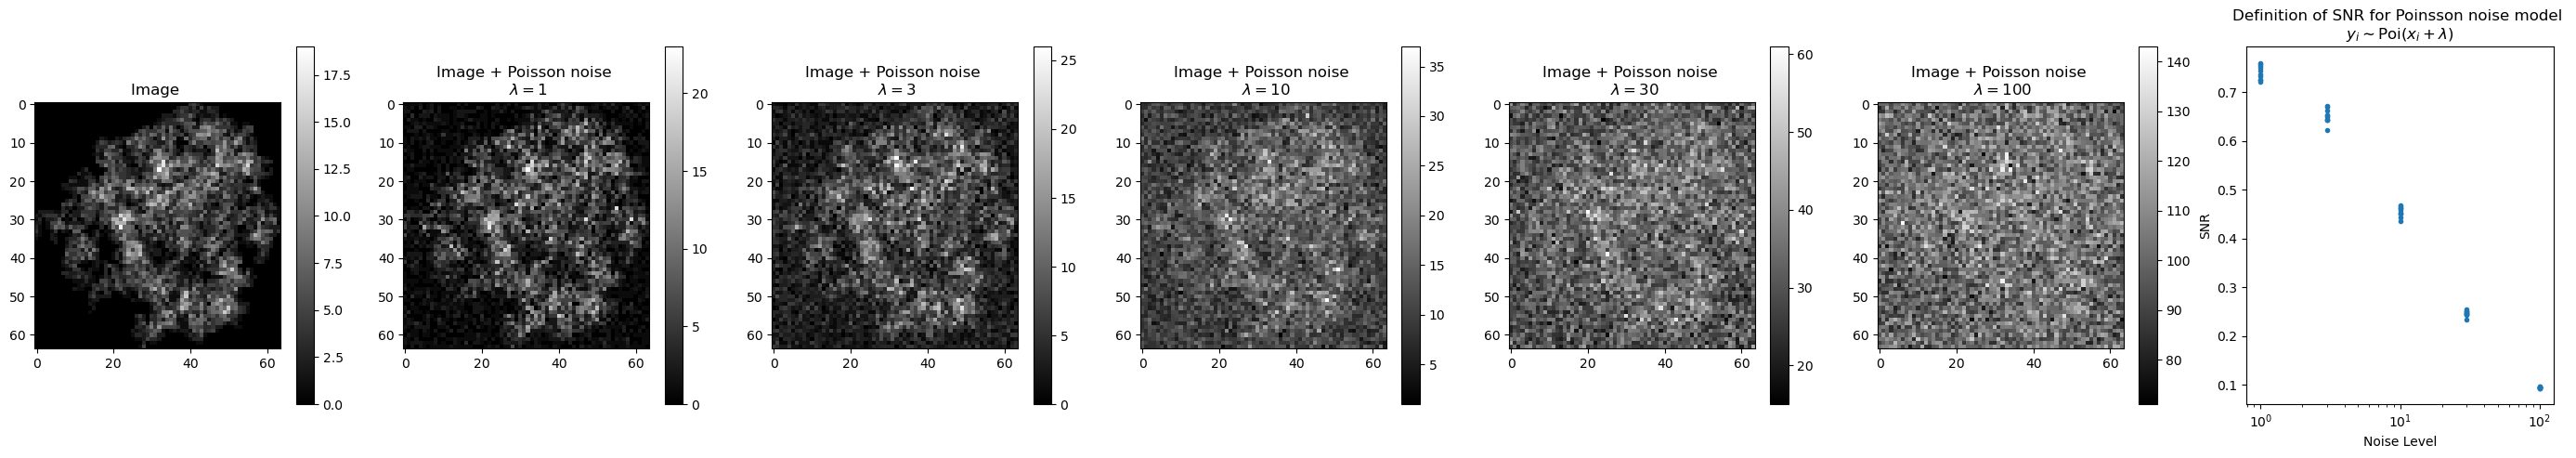

In [43]:
noise_levels = torch.tensor([1,3,10, 30, 100])
snrs = []
base = 5
n_plots = len(noise_levels) + 2
fig, axes = plt.subplots(1, n_plots, figsize=(base*n_plots, base))


im = axes[0].imshow(image, cmap='gray')
fig.colorbar(im, ax=axes[0])
axes[0].set_title('Image ')

for idx, lam_noise in enumerate(noise_levels):

    n_random_redraws = 10
    noise_var = torch.zeros(n_random_redraws)
    for i in range(n_random_redraws):

        image_noise = torch.distributions.Poisson(torch.from_numpy(image) + lam_noise).sample().numpy()
        noise_var[i] = image_noise.var().mean()
        # plot two images next to each other

    im = axes[1+idx].imshow(image_noise, cmap='gray')
    fig.colorbar(im, ax=axes[1+idx])
    axes[1+idx].set_title('Image + Poisson noise \n '+r'$\lambda=${:1.0f}'.format(lam_noise))

    snrs.extend(image.var().mean() / noise_var)

axes[idx+2].scatter(noise_levels.repeat(n_random_redraws,1).T.flatten(), snrs, marker='.')
axes[idx+2].set_title('Definition of SNR for Poinsson noise model \n'+ r'$y_i \sim \text{Poi}(x_i+\lambda)$')
axes[idx+2].set_xlabel('Noise Level')
axes[idx+2].set_ylabel('SNR')
axes[idx+2].set_xscale('log')






# $lambda$ = 3

In [ ]:
deg = 25
lam_noise = 3
image_noise = torch.distributions.Poisson(torch.from_numpy(image) + lam_noise).sample().numpy()
rotation = R.from_euler('z', deg, degrees=True).as_matrix().astype(np.float32)
transport_plan, rotation_est, logs = procrustes_wasserstein_2d_3d_dram_prob(all_coords_subset_scaled @ rotation, UV, UV_ditribution = torch.from_numpy(image_noise.flatten() / image_noise.sum()), max_iter=40, verbose_log=True, emd_kwargs={'numItermax':10**6})
error = np.linalg.norm(rotation_est - rotation)
rotation, rotation_est, error

NameError: name 'all_coords_subset_scaled' is not defined